In [1]:
cd("/home/ritaferi/Phd/SSDdev/")
using Pkg
Pkg.activate(".")
Pkg.instantiate()

using SolidStateDetectors
using Unitful
using Plots
using LegendHDF5IO


  Activating project at `~/Phd/SSDdev`
Precompiling packages...
  15220.9 ms  ✓ SolidStateDetectors
  1 dependency successfully precompiled in 19 seconds. 324 already precompiled.


In [2]:
refinement_limits = [0.2, 0.1, 0.05, 0.02]

#-------- ICPC vuoto -----------
save_sim_path = "saved_simulation/sim.h5"

"saved_simulation/sim.h5"

In [3]:
println("⚡ Upoload simulation saved in : $save_sim_path")
sim = ssd_read(save_sim_path, Simulation)

⚡ Upoload simulation saved in : saved_simulation/sim.h5
Simulation{Float32, Cylindrical} - Coordinate system: Cylindrical
  Environment Material: Vacuum
  Detector: Public Inverted Coax
  Electric potential: (438, 1, 560)
  Charge density: (438, 1, 560)
  Impurity scale: (438, 1, 560)
  Fix Charge density: (438, 1, 560)
  Dielectric distribution: (439, 2, 561)
  Point types: (438, 1, 560)
  Electric field: missing
  Weighting potentials: 
    Contact 1: missing
    Contact 2: missing


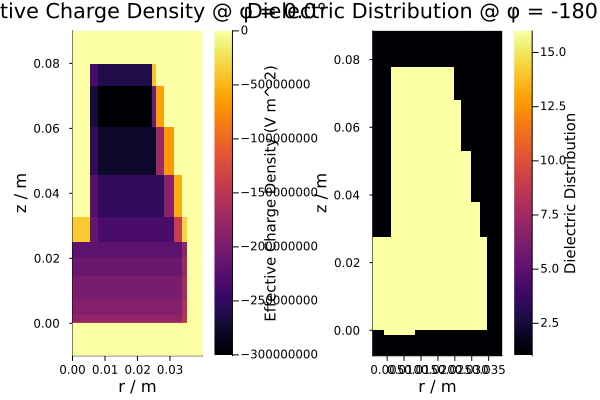

In [ ]:
apply_initial_state!(sim, ElectricPotential)

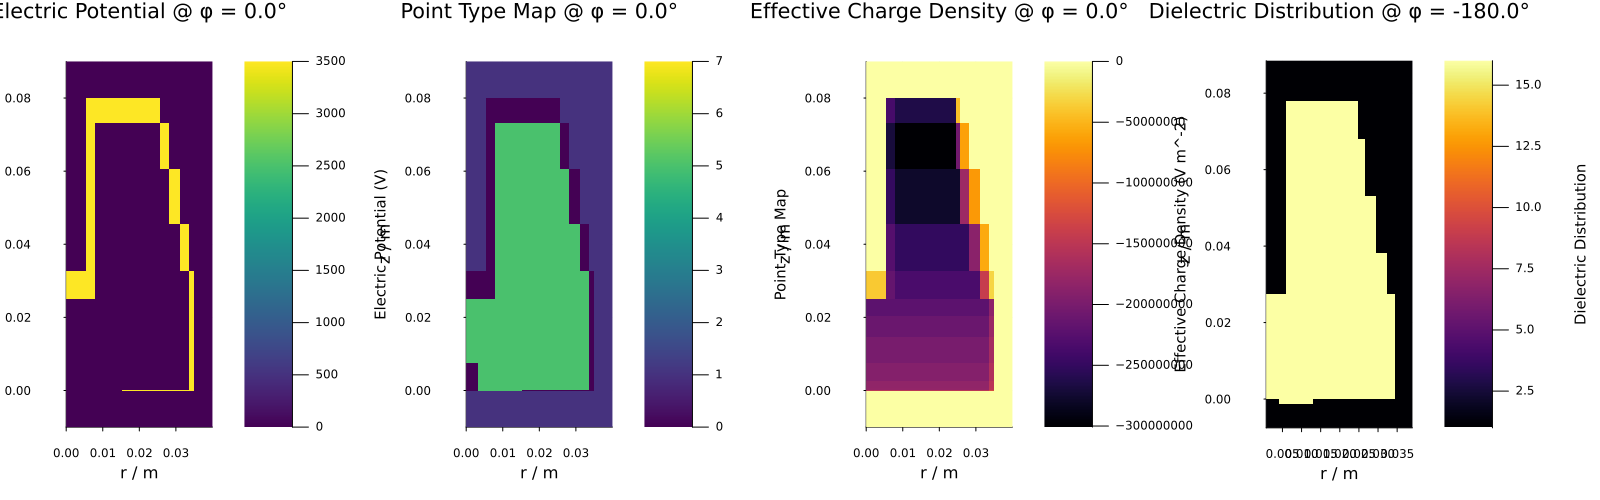

In [5]:
plot(
    plot(sim.electric_potential), # initial electric potential (boundary conditions)
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)

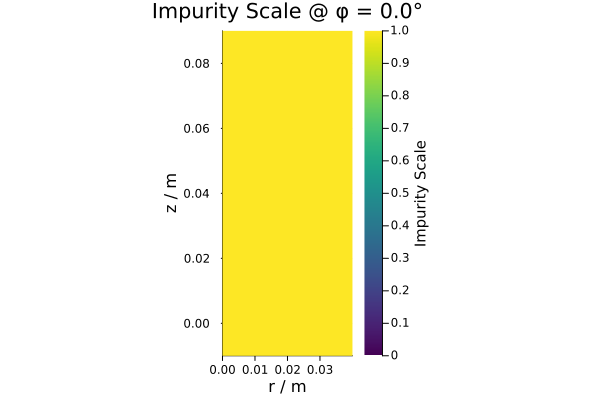

In [10]:
plot(sim.imp_scale)

In [11]:
is_depleted(sim.point_types)

true

## Undepleted

In [12]:
sim_undep = deepcopy(sim)
sim_undep.detector = SolidStateDetector(sim_undep.detector, contact_id = 2, contact_potential = 500); # V  <-- Bias Voltage of Mantle


In [13]:
calculate_electric_potential!( sim_undep,
                               depletion_handling = true,
                               convergence_limit = 1e-6,
                               refinement_limits = [0.2, 0.1, 0.05, 0.01],
                               verbose = false)